# 05 — Explainability and Clinical Cost Analysis
**Project:** Predicting Medication Non-Adherence in NCD Patients Using Classical Machine Learning  
**Dataset:** Kanyongo et al. (2024); Cimas Medical Aid Society, Zimbabwe ([Mendeley Data](https://data.mendeley.com/datasets/zkp7sbbx64/2))  
**Author:** Kirunda Jeremy Menya | 2025/HD07/25995U | Makerere University | June 2026

---

This notebook covers:
1. Environment setup, SSH, and repo clone
2. Load all inputs: feature group splits, best tuned model, and tuned results
3. Feature group experiment: evaluate the best model on Groups A, B, and C
4. Feature group comparison visualisation
5. SHAP global explainability: beeswarm plot, mean absolute SHAP bar chart, group dominance
6. SHAP dependence plots for the three highest-importance features
7. SHAP local explainability: waterfall plots for individual patient predictions
8. Clinical cost-sensitive evaluation: define the cost matrix and compute cost scores across all models
9. Clinical cost comparison visualisation
10. Final evaluation of the best model on the held-out test set
11. Summary of findings and policy implications
12. Save all outputs and push to GitHub

**Inputs:** `data/processed/features_A.pkl`, `features_B.pkl`, `features_C.pkl`, `data/processed/tuned_results.pkl`, `models/tuned_xgboost_calibrated.pkl`, `models/tuned_rf_calibrated.pkl`, `models/baseline_*.pkl`  
**Outputs:** `data/processed/final_results.pkl`, SHAP figures, cost analysis figures, feature group comparison figure

---
## 0. Environment Setup

`shap` is not pre-installed on Colab and needs to be installed before the imports. Everything else used here was already installed in Notebooks 03 and 04. Imports and helpers are redefined so this notebook can be run independently without requiring any earlier notebook to be open in the same session.

In [1]:
# Install dependencies not pre-installed on Colab
!pip install shap imbalanced-learn xgboost --quiet

import os, warnings, pickle
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap

from sklearn.compose         import ColumnTransformer
from sklearn.preprocessing   import StandardScaler, RobustScaler
from sklearn.metrics         import (
    accuracy_score, f1_score, roc_auc_score, matthews_corrcoef,
    precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.pipeline       import Pipeline as ImbPipeline
from imblearn.over_sampling  import SMOTE
from sklearn.ensemble        import RandomForestClassifier
from xgboost                 import XGBClassifier

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "figure.dpi":        150,
})

PALETTE = {
    "adherent":     "#2196F3",
    "non_adherent": "#F44336",
    "neutral":      "#78909C",
    "highlight":    "#FF9800",
    "dark_grey":    "#455A64",
    "group_a":      "#9C27B0",
    "group_b":      "#00897B",
    "group_c":      "#1565C0",
    "xgb":          "#AD1457",
    "rf":           "#2E7D32",
}

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.4f}".format)

def section(title):
    bar = "\u2500" * 70
    print(f"\n{bar}\n  {title}\n{bar}")

print("Imports ready.")

Imports ready.


---
## 0.1 SSH Key Upload and Repository Clone

The repository is cloned into the Colab runtime at the start of each session. The SSH deploy key authenticates the clone and allows the notebook to push its outputs to GitHub at the end.

In [2]:
from google.colab import files

os.makedirs('/root/.ssh', exist_ok=True)
uploaded = files.upload()   # select DMHTN_MedicationAdherence_deploy_key (NOT .pub)

!mv DMHTN_MedicationAdherence_deploy_key /root/.ssh/DMHTN_MedicationAdherence_deploy_key
!chmod 600 /root/.ssh/DMHTN_MedicationAdherence_deploy_key

ssh_config = """
Host github-dmhtn-medication-adherence
    HostName github.com
    User git
    IdentityFile /root/.ssh/DMHTN_MedicationAdherence_deploy_key
"""
with open('/root/.ssh/config', 'w') as f:
    f.write(ssh_config)
!chmod 600 /root/.ssh/config
!ssh-keyscan github.com >> /root/.ssh/known_hosts 2>/dev/null

REPO_NAME = 'diabetes-hypertension-medication-adherence'
if not os.path.exists(f'/content/{REPO_NAME}'):
    !git clone git@github-dmhtn-medication-adherence:Jeremy-K-coder/diabetes-hypertension-medication-adherence.git

%cd /content/{REPO_NAME}
!git config --global user.email "jeremykirunda58@gmail.com"
!git config --global user.name "Jeremy Kirunda"
!git pull
print('Repo ready.')

Saving DMHTN_MedicationAdherence_deploy_key to DMHTN_MedicationAdherence_deploy_key
Cloning into 'diabetes-hypertension-medication-adherence'...
remote: Enumerating objects: 100, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 100 (delta 28), reused 88 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (100/100), 21.48 MiB | 5.21 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/diabetes-hypertension-medication-adherence
Already up to date.
Repo ready.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
REPO_DIR  = f'/content/{REPO_NAME}'
DATA_PROC = os.path.join(REPO_DIR, 'data', 'processed')
MODELS    = os.path.join(REPO_DIR, 'models')
FIGURES   = os.path.join(REPO_DIR, 'figures')

DRIVE_BASE   = '/content/drive/MyDrive/diabetes-hypertension-medication-adherence'
DRIVE_PROC   = os.path.join(DRIVE_BASE, 'data', 'processed')
DRIVE_MODELS = os.path.join(DRIVE_BASE, 'models')

os.makedirs(DATA_PROC,                   exist_ok=True)
os.makedirs(MODELS,                      exist_ok=True)
os.makedirs(f"{FIGURES}/shap",           exist_ok=True)
os.makedirs(f"{FIGURES}/cost_analysis",  exist_ok=True)
os.makedirs(f"{FIGURES}/feature_group",  exist_ok=True)

def save_figure(fig, filename, subfolder="shap"):
    path = f"{FIGURES}/{subfolder}/{filename}"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved \u2192 {path}")

print(f"REPO_DIR  : {REPO_DIR}")
print(f"DATA_PROC : {DATA_PROC}")
print(f"MODELS    : {MODELS}")
print(f"FIGURES   : {FIGURES}")

REPO_DIR  : /content/diabetes-hypertension-medication-adherence
DATA_PROC : /content/diabetes-hypertension-medication-adherence/data/processed
MODELS    : /content/diabetes-hypertension-medication-adherence/models
FIGURES   : /content/diabetes-hypertension-medication-adherence/figures


---
## 1. Load All Inputs

This notebook draws on outputs from Notebooks 02, 03, and 04. Loading everything at the start confirms that all upstream steps completed successfully before any analysis begins.

`features_A.pkl`, `features_B.pkl`, and `features_C.pkl` each contain a train, validation, and test split for their respective feature group. These were defined in Notebook 02 and have been held constant across every notebook since, so the splits used here are identical to those used during training. `tuned_results.pkl` records the best model name, its hyperparameters, and its calibration outcome from Notebook 04. The best calibrated model pipeline is loaded directly from the `models/` folder.

The test set is used for the first time in this notebook. It has been held back completely since Notebook 02 and has played no part in any model fitting, hyperparameter selection, or calibration decision up to this point. This is what makes the test set evaluation in Section 9 a genuine estimate of how the model would perform on new patients.

In [5]:
section("1. Load all inputs")

def load_pkl(path=DATA_PROC):
    with open(path, "rb") as f:
        return pickle.load(f)

# Feature group splits
pkg_A = load_pkl(os.path.join(DATA_PROC, "features_A.pkl"))
pkg_B = load_pkl(os.path.join(DATA_PROC, "features_B.pkl"))
pkg_C = load_pkl(os.path.join(DATA_PROC, "features_C.pkl"))

# Tuning results and best model identity from Notebook 04
tuned_results   = load_pkl(os.path.join(DATA_PROC,   "tuned_results.pkl"))
BEST_MODEL_NAME = tuned_results["best_model_name"]

# Best calibrated pipelines saved by Notebook 04
best_pipeline = load_pkl(os.path.join(MODELS, "tuned_xgboost_calibrated.pkl"))
rf_pipeline   = load_pkl(os.path.join(MODELS, "tuned_rf_calibrated.pkl"))

# Unpack Group C splits used throughout this notebook
X_train_C  = pkg_C["X_train"]
X_val_C    = pkg_C["X_val"]
X_test_C   = pkg_C["X_test"]
y_train_C  = pkg_C["y_train"]
y_val_C    = pkg_C["y_val"]
y_test_C   = pkg_C["y_test"]
FEATURES_C = pkg_C["features"]

TARGET = "adherence"

print(f"Best model from Notebook 04: {BEST_MODEL_NAME}")
print()
print(f"Group A features : {pkg_A['features']}")
print(f"Group B features : {pkg_B['features']}")
print(f"Group C features : {FEATURES_C}")
print()
print("Group C splits:")
print(f"  Train      : {X_train_C.shape}  | adherent: {y_train_C.mean()*100:.1f}%")
print(f"  Validation : {X_val_C.shape}  | adherent: {y_val_C.mean()*100:.1f}%")
print(f"  Test       : {X_test_C.shape}  | adherent: {y_test_C.mean()*100:.1f}%")


──────────────────────────────────────────────────────────────────────
  1. Load all inputs
──────────────────────────────────────────────────────────────────────
Best model from Notebook 04: XGBoost (Isotonic)

Group A features : ['insurance_tier', 'cost_burden_ratio', 'age_group', 'gender']
Group B features : ['unitstotal', 'annualclaimamount', 'annualcontribution']
Group C features : ['insurance_tier', 'cost_burden_ratio', 'age_group', 'gender', 'unitstotal', 'annualclaimamount', 'annualcontribution', 'is_comorbid', 'diagnosis', 'complication_flag']

Group C splits:
  Train      : (16849, 10)  | adherent: 40.2%
  Validation : (3611, 10)  | adherent: 40.2%
  Test       : (3611, 10)  | adherent: 40.2%


---
## 2. Feature Group Experiment

This is the core analytical contribution of the project. The dataset contains two distinct kinds of information about each patient: socioeconomic information derived from insurance records (age, gender, scheme type, cover type) and clinical consumption information derived from pharmacy records (annual claim amount, units dispensed, annual contribution, and the engineered cost burden ratio). These were separated into Group A and Group B in Notebook 02.

The experiment asks three related questions. First, does a model trained only on socioeconomic information (Group A) predict adherence at a meaningful level? Second, does adding pharmacy consumption data (Group B) improve substantially on that? Third, does combining everything (Group C) add further value over Group B alone?

This comparison has direct implications for how a screening programme would be designed in practice. Community health workers in Zimbabwe typically have access to patient registration and insurance records but not necessarily to pharmacy dispensing logs. If Group A achieves performance close to Group B, it means adherence risk can be estimated from the data a CHW already has. If Group B substantially outperforms Group A, it argues that integrating pharmacy data is worth the additional data collection effort.

The experiment runs on the best tuned model from Notebook 04 rather than on an untuned baseline. Using an untuned model would risk drawing conclusions that depend on how well default hyperparameters happen to suit each feature group rather than on the actual information content of the features themselves. Running on the tuned model ensures the comparison reflects the best performance achievable from each feature set.

The preprocessing pipeline is rebuilt for each feature group using only the features available in that group. Group A contains no skewed continuous financial variables so it does not use `RobustScaler`. Group B contains `annualclaimamount`, `unitstotal`, and `cost_burden_ratio`, all of which were found to be highly skewed in Notebook 01, so these go through `RobustScaler`. Group C inherits the full preprocessing logic. SMOTE is applied inside each pipeline at training time to handle the class imbalance identified in Notebook 01 (14,415 non-adherent vs 9,669 adherent patients; a 1.49x imbalance ratio).

### 2.1 Rebuild the Adaptive Pipeline Helper

The pipeline constructor is redefined here so that it accepts any feature list and builds the correct preprocessing steps for whichever features are present in that group. This avoids having to hardcode separate pipeline definitions for each group.

In [6]:
section("2.1 Rebuild adaptive pipeline helper")

ROBUST_FEATURES_ALL   = ["annualclaimamount", "unitstotal", "cost_burden_ratio"]
STANDARD_FEATURES_ALL = ["annualcontribution"]
PASSTHROUGH_ALL       = ["insurance_tier", "age_group", "is_comorbid",
                         "complication_flag", "gender", "diagnosis"]

def build_preprocessor_for_group(feature_list):
    """Build a ColumnTransformer using only the columns present in feature_list."""
    transformers = []
    robust   = [f for f in ROBUST_FEATURES_ALL   if f in feature_list]
    standard = [f for f in STANDARD_FEATURES_ALL if f in feature_list]
    passthru = [f for f in PASSTHROUGH_ALL        if f in feature_list]

    if robust:
        transformers.append(("robust",   RobustScaler(),   robust))
    if standard:
        transformers.append(("standard", StandardScaler(), standard))
    if passthru:
        transformers.append(("pass",     "passthrough",    passthru))

    return ColumnTransformer(transformers=transformers, remainder="drop")

def build_group_pipeline(clf, feature_list):
    return ImbPipeline(steps=[
        ("preprocessor", build_preprocessor_for_group(feature_list)),
        ("smote",        SMOTE(random_state=SEED)),
        ("classifier",   clf),
    ])

def evaluate_group(pipeline, X_tr, y_tr, X_ev, y_ev, label):
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_ev)
    y_prob = pipeline.predict_proba(X_ev)[:, 1]
    return {
        "Group":              label,
        "Accuracy":           round(accuracy_score(y_ev, y_pred), 4),
        "Macro F1":           round(f1_score(y_ev, y_pred, average="macro"), 4),
        "Weighted F1":        round(f1_score(y_ev, y_pred, average="weighted"), 4),
        "ROC-AUC":            round(roc_auc_score(y_ev, y_prob), 4),
        "MCC":                round(matthews_corrcoef(y_ev, y_pred), 4),
        "Precision (Non-Adh)": round(precision_score(y_ev, y_pred, pos_label=0), 4),
        "Recall (Non-Adh)":   round(recall_score(y_ev, y_pred, pos_label=0), 4),
        "_pipeline":          pipeline,
    }

print("Pipeline helpers and evaluation function ready.")


──────────────────────────────────────────────────────────────────────
  2.1 Rebuild adaptive pipeline helper
──────────────────────────────────────────────────────────────────────
Pipeline helpers and evaluation function ready.


### 2.2 Run the Experiment

Each group is trained on its own training split and evaluated on its own validation split. The best XGBoost hyperparameters from Notebook 04 are applied across all three groups so that the only variable between runs is the feature set. Model capacity settings are held constant, which means any performance difference between groups is attributable to the features rather than to the model configuration.

In [7]:
section("2.2 Feature group experiment")

xgb_best_params = {
    k.replace("classifier__", ""): v
    for k, v in tuned_results["xgb_best_params"].items()
}

group_pipelines = {}
group_rows = []

for group_label, pkg in [
    ("A: Socioeconomic",       pkg_A),
    ("B: Clinical Consumption", pkg_B),
    ("C: Combined",            pkg_C),
]:
    features = pkg["features"]
    clf = XGBClassifier(
        **xgb_best_params,
        random_state=SEED,
        eval_metric="logloss",
        verbosity=0,
        n_jobs=-1
    )
    pipeline = build_group_pipeline(clf, features)

    print(f"Training on {group_label} ({len(features)} features)...", end=" ", flush=True)
    row = evaluate_group(
        pipeline,
        pkg["X_train"], pkg["y_train"],
        pkg["X_val"],   pkg["y_val"],
        group_label
    )
    group_pipelines[group_label] = row.pop("_pipeline")
    group_rows.append(row)
    print(f"done  |  Macro F1: {row['Macro F1']}  |  ROC-AUC: {row['ROC-AUC']}  |  MCC: {row['MCC']}")

df_groups = pd.DataFrame(group_rows).set_index("Group")

print()
print("Feature group experiment complete.")
print()
print(df_groups.to_string())


──────────────────────────────────────────────────────────────────────
  2.2 Feature group experiment
──────────────────────────────────────────────────────────────────────
Training on A: Socioeconomic (4 features)... done  |  Macro F1: 0.7338  |  ROC-AUC: 0.8212  |  MCC: 0.5057
Training on B: Clinical Consumption (3 features)... done  |  Macro F1: 0.8071  |  ROC-AUC: 0.8899  |  MCC: 0.6398
Training on C: Combined (10 features)... done  |  Macro F1: 0.8148  |  ROC-AUC: 0.9025  |  MCC: 0.6454

Feature group experiment complete.

                         Accuracy  Macro F1  Weighted F1  ROC-AUC    MCC  Precision (Non-Adh)  Recall (Non-Adh)
Group                                                                                                          
A: Socioeconomic           0.7341    0.7338       0.7357   0.8212 0.5057               0.8783            0.6449
B: Clinical Consumption    0.8081    0.8071       0.8098   0.8899 0.6398               0.9287            0.7356
C: Combined      

---
## 3. Feature Group Comparison Visualisation

The bar chart below shows the validation set performance of the best tuned model across all three feature groups. Four metrics are shown: Macro F1, ROC-AUC, MCC, and Recall on the non-adherent class. Macro F1 is the primary metric because it treats both classes equally, which matters given the class imbalance in the dataset. Recall on the non-adherent class is shown separately because missing a non-adherent patient (a false negative) is the most costly type of error in this clinical setting, as formalised in Section 7.

Reading across the bars answers the central research question: does Group A (insurance and demographic data that a CHW already has) come close to Group B (pharmacy consumption data that requires an integrated health information system)? The gap between the two groups, and the additional gain from combining them in Group C, together determine what data infrastructure a real deployment would need to justify.


──────────────────────────────────────────────────────────────────────
  3. Feature group comparison visualisation
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/feature_group/feature_group_comparison.png


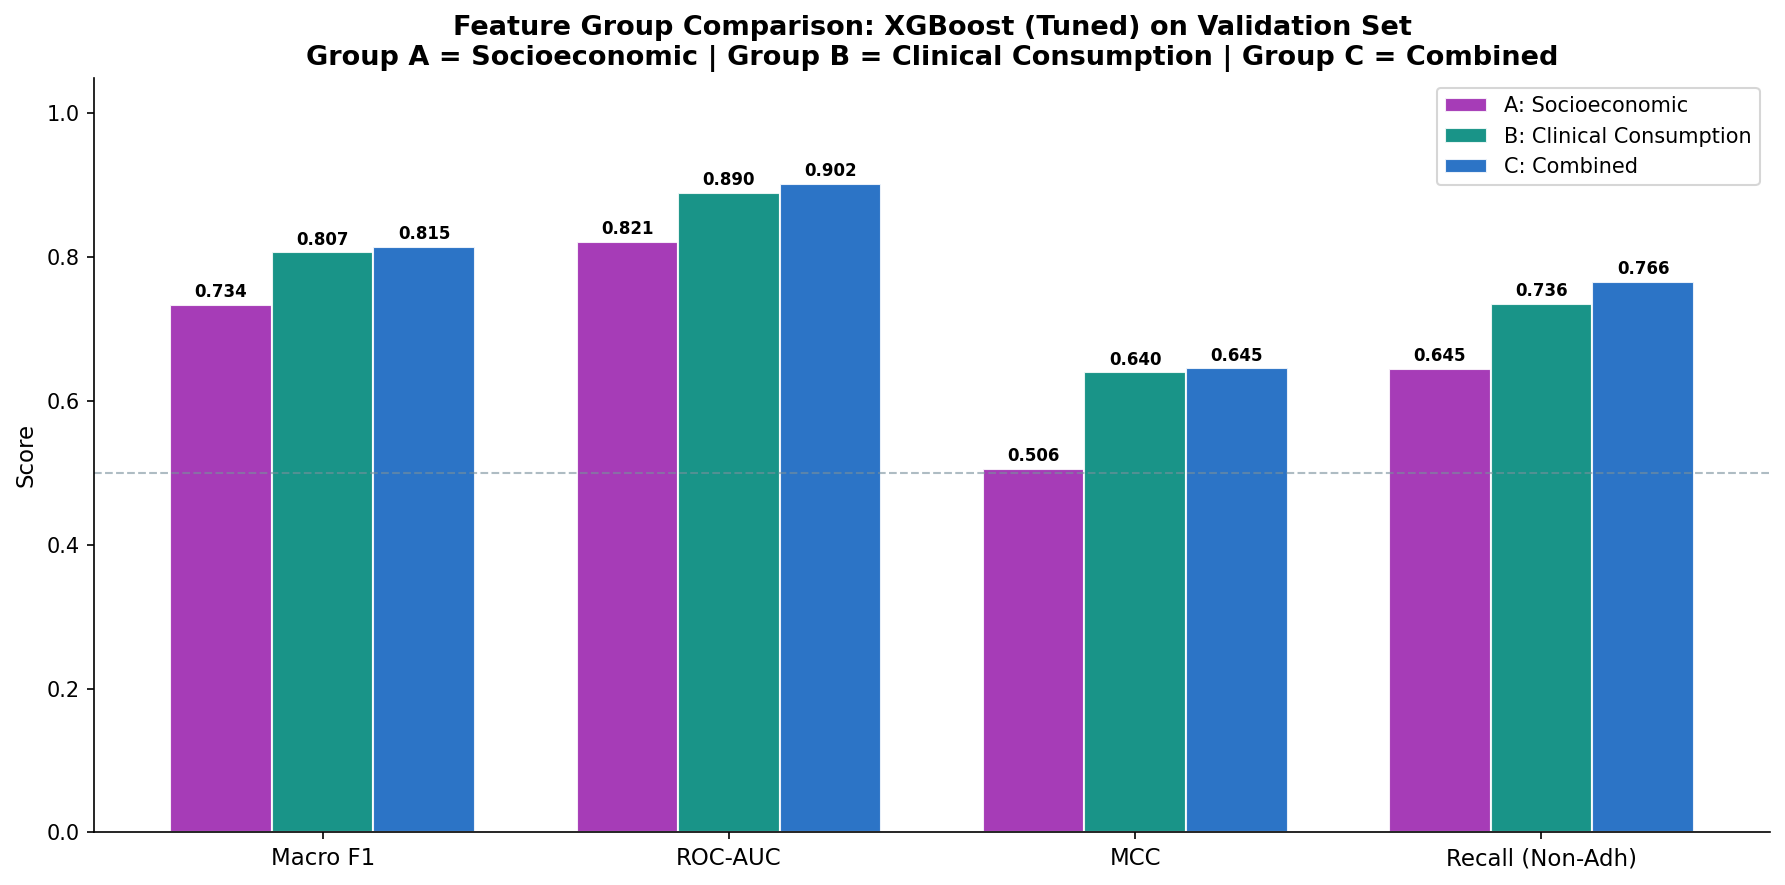


Key finding:
  Group A (Socioeconomic)       Macro F1: 0.7338
  Group B (Clinical Consump.)   Macro F1: 0.8071
  Group C (Combined)            Macro F1: 0.8148
  Gap (B minus A): +0.0733  |  Gap (C minus B): +0.0077


In [8]:
section("3. Feature group comparison visualisation")

metric_cols_group = ["Macro F1", "ROC-AUC", "MCC", "Recall (Non-Adh)"]
group_colours     = [PALETTE["group_a"], PALETTE["group_b"], PALETTE["group_c"]]

x      = np.arange(len(metric_cols_group))
width  = 0.25
offsets= [-width, 0, width]

fig, ax = plt.subplots(figsize=(12, 6))

for i, (group_label, colour) in enumerate(zip(df_groups.index, group_colours)):
    vals = [df_groups.loc[group_label, m] for m in metric_cols_group]
    bars = ax.bar(x + offsets[i], vals, width, label=group_label,
                  color=colour, edgecolor="white", alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(metric_cols_group, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title(
    "Feature Group Comparison: XGBoost (Tuned) on Validation Set\n"
    "Group A = Socioeconomic | Group B = Clinical Consumption | Group C = Combined",
    fontweight="bold"
)
ax.legend(fontsize=10)
ax.axhline(0.5, color=PALETTE["neutral"], linestyle="--", linewidth=1,
           alpha=0.6, label="Random baseline")
plt.tight_layout()
save_figure(fig, "feature_group_comparison.png", subfolder="feature_group")
plt.show()

print()
print("Key finding:")
print(f"  Group A (Socioeconomic)       Macro F1: {df_groups.loc['A: Socioeconomic', 'Macro F1']:.4f}")
print(f"  Group B (Clinical Consump.)   Macro F1: {df_groups.loc['B: Clinical Consumption', 'Macro F1']:.4f}")
print(f"  Group C (Combined)            Macro F1: {df_groups.loc['C: Combined', 'Macro F1']:.4f}")
gap_AB = df_groups.loc["B: Clinical Consumption", "Macro F1"] - df_groups.loc["A: Socioeconomic", "Macro F1"]
gap_CB = df_groups.loc["C: Combined", "Macro F1"] - df_groups.loc["B: Clinical Consumption", "Macro F1"]
print(f"  Gap (B minus A): {gap_AB:+.4f}  |  Gap (C minus B): {gap_CB:+.4f}")

---
## 4. SHAP Global Explainability

Standard machine learning models, particularly tree ensembles like XGBoost, are not inherently interpretable. A model can achieve good predictive performance while using features in ways that are unexpected, counterintuitive, or clinically problematic. SHAP (SHapley Additive exPlanations) addresses this by providing a principled way to attribute each prediction to its contributing features.

SHAP values are grounded in cooperative game theory. Each feature's contribution to a particular prediction is calculated as its average marginal contribution across all possible orderings in which it could be added to the model. This gives every prediction a complete decomposition into feature contributions that sum exactly to the difference between that prediction and the model's average prediction across the training set.

Three specific questions guide this section:

**Group dominance:** When both socioeconomic (Group A) and clinical consumption (Group B) features are present together in Group C, which group carries more weight in the model's predictions? This is a more nuanced version of the feature group experiment because it shows how the model balances the two groups when both are available, not how each performs in isolation.

**Direction of effects:** Does a higher `cost_burden_ratio` push predictions toward non-adherence as expected from the hypothesis that financial strain reduces adherence? Does having a complication push toward non-adherence? The beeswarm plot answers these questions for every feature simultaneously.

**Comorbidity effect:** The EDA in Notebook 01 found that comorbid patients showed a somewhat counterintuitive pattern in adherence rates. The SHAP values will show whether the model has picked up on this pattern and in which direction it is using the comorbidity flag.

`TreeExplainer` is used because the best model is a tree-based ensemble. `TreeExplainer` computes exact SHAP values for tree models without the sampling approximations required by the general `KernelExplainer`, making it both faster and more precise. SHAP values are computed on the test set so the explanations reflect the model's behaviour on data it has never seen during training or tuning. A random subsample of 1,500 test patients is used for the beeswarm and dependence plots to keep rendering time manageable; mean absolute SHAP values used for ranking are computed on the full test set.

### 4.1 Fit the SHAP TreeExplainer

The pipeline contains a preprocessing step before the classifier. `TreeExplainer` works directly on the tree model, not the sklearn pipeline wrapper, so the test data is passed through the preprocessor separately before SHAP values are computed. The feature names after the `ColumnTransformer` are reconstructed in transformer order (robust first, then standard, then passthrough) so the plots display readable column labels rather than generic indices.

In [9]:
section("4.1 Fit SHAP TreeExplainer")

best_pipeline_C = group_pipelines["C: Combined"]

X_test_transformed = best_pipeline_C.named_steps["preprocessor"].transform(X_test_C)

ROBUST_FEATURES   = [f for f in ["annualclaimamount", "unitstotal", "cost_burden_ratio"] if f in FEATURES_C]
STANDARD_FEATURES = [f for f in ["annualcontribution"] if f in FEATURES_C]
PASSTHROUGH       = [f for f in ["insurance_tier", "age_group", "is_comorbid",
                                  "complication_flag", "gender", "diagnosis"] if f in FEATURES_C]
TRANSFORMED_FEATURE_NAMES = ROBUST_FEATURES + STANDARD_FEATURES + PASSTHROUGH

xgb_classifier = best_pipeline_C.named_steps["classifier"]

explainer   = shap.TreeExplainer(xgb_classifier)
shap_values = explainer.shap_values(X_test_transformed)

print(f"SHAP values computed for {X_test_transformed.shape[0]} test patients.")
print(f"Feature names (in transformer order): {TRANSFORMED_FEATURE_NAMES}")
print(f"SHAP value matrix shape: {shap_values.shape}")


──────────────────────────────────────────────────────────────────────
  4.1 Fit SHAP TreeExplainer
──────────────────────────────────────────────────────────────────────
SHAP values computed for 3611 test patients.
Feature names (in transformer order): ['annualclaimamount', 'unitstotal', 'cost_burden_ratio', 'annualcontribution', 'insurance_tier', 'age_group', 'is_comorbid', 'complication_flag', 'gender', 'diagnosis']
SHAP value matrix shape: (3611, 10)


### 4.2 Beeswarm Plot

The beeswarm plot shows one point per patient per feature. The x-axis is the SHAP value: points to the right pushed the model's prediction toward adherence (positive SHAP) and points to the left pushed it toward non-adherence (negative SHAP). Point colour represents the raw feature value for that patient, with red indicating a high feature value and blue indicating a low one.

Reading position and colour together reveals the direction of each feature's effect. For example, if the points for `cost_burden_ratio` are clustered to the left and coloured red, it means patients with a high cost burden ratio were pushed toward a non-adherence prediction. If `annualclaimamount` points are clustered to the right with red colouring, it means patients with high claim amounts were predicted as more adherent, which would be consistent with the idea that higher claim amounts reflect more active medication use. Features are ranked top to bottom by mean absolute SHAP value, so the most influential features appear at the top.


──────────────────────────────────────────────────────────────────────
  4.2 SHAP beeswarm plot
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/shap/shap_beeswarm.png


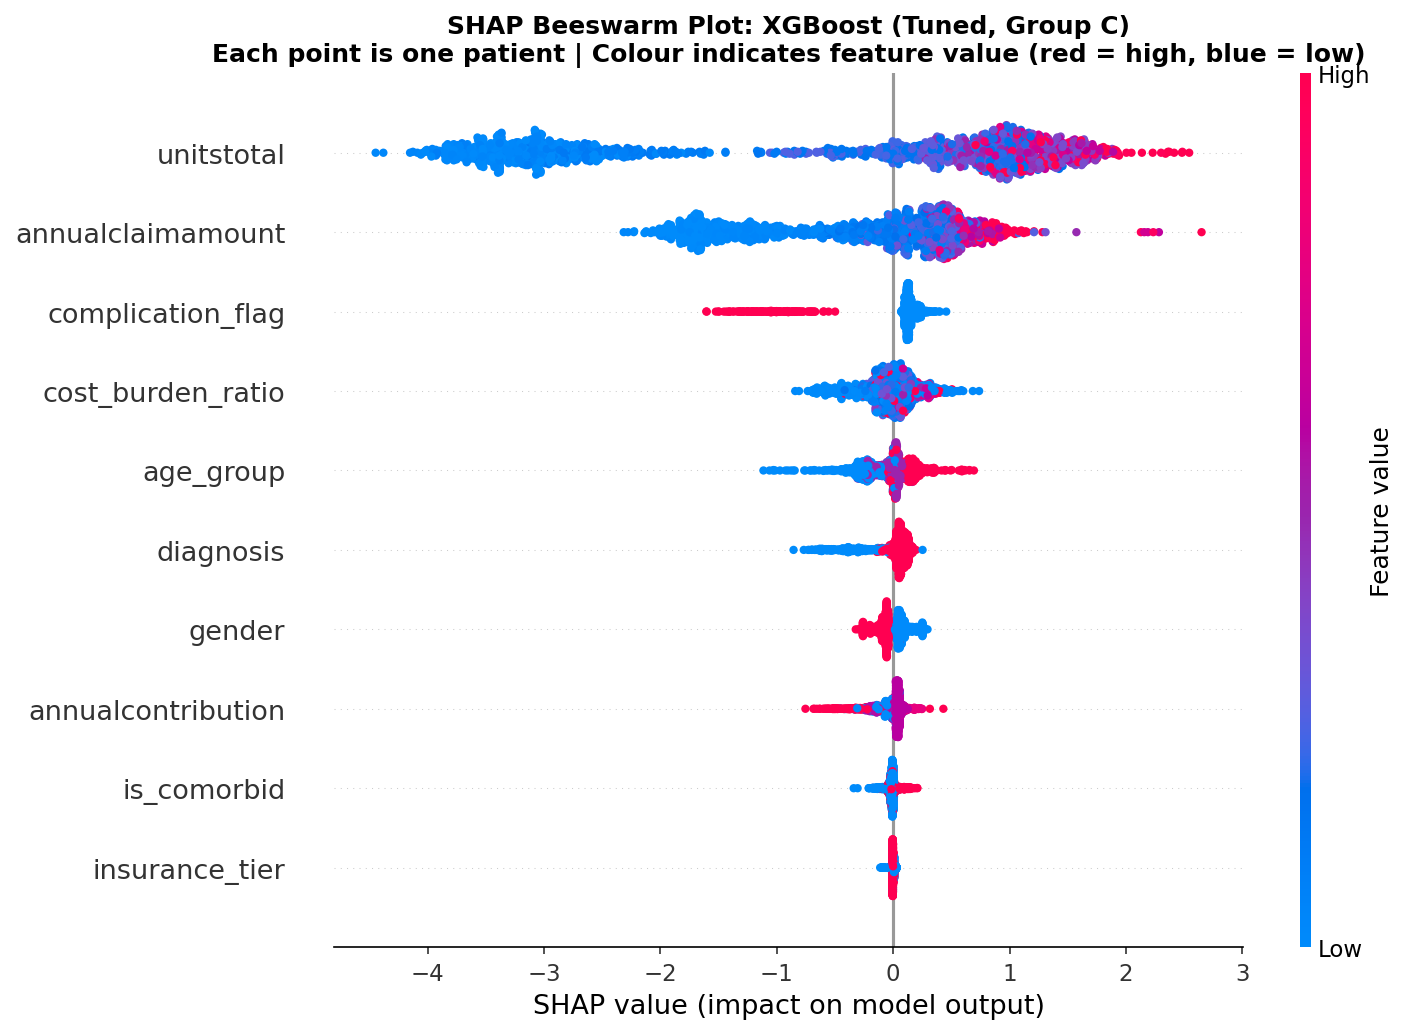

In [10]:
section("4.2 SHAP beeswarm plot")

SUBSAMPLE_N = 1500
rng = np.random.default_rng(SEED)
subsample_idx = rng.choice(
    len(X_test_transformed),
    size=min(SUBSAMPLE_N, len(X_test_transformed)),
    replace=False
)

shap_sub = shap_values[subsample_idx]
X_sub    = X_test_transformed[subsample_idx]

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_sub,
    X_sub,
    feature_names=TRANSFORMED_FEATURE_NAMES,
    plot_type="dot",
    show=False,
    max_display=len(TRANSFORMED_FEATURE_NAMES),
    plot_size=None
)
plt.title(
    "SHAP Beeswarm Plot: XGBoost (Tuned, Group C)\n"
    "Each point is one patient | Colour indicates feature value (red = high, blue = low)",
    fontweight="bold", fontsize=12
)
plt.tight_layout()
save_figure(fig, "shap_beeswarm.png", subfolder="shap")
plt.show()

### 4.3 Mean Absolute SHAP Bar Chart (Global Feature Importance)

Mean absolute SHAP values are the most reliable measure of global feature importance for tree models. The default feature importance scores built into XGBoost and Random Forest are based on how frequently a feature is used to split nodes during training (impurity-based importance). These can be misleading because they are computed on the training data and tend to overstate the importance of high-cardinality or continuous features. Mean absolute SHAP values are computed on test set predictions and reflect actual average contribution to those predictions regardless of feature type.

Bars are colour-coded by feature group: purple for Group A (socioeconomic), teal for Group B (clinical consumption), and grey for features that provide clinical context (comorbidity status, diagnosis, complication flag). This colour coding connects the importance ranking back to the feature group experiment in Section 2.


──────────────────────────────────────────────────────────────────────
  4.3 Mean absolute SHAP values: global feature importance
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/shap/shap_feature_importance_bar.png


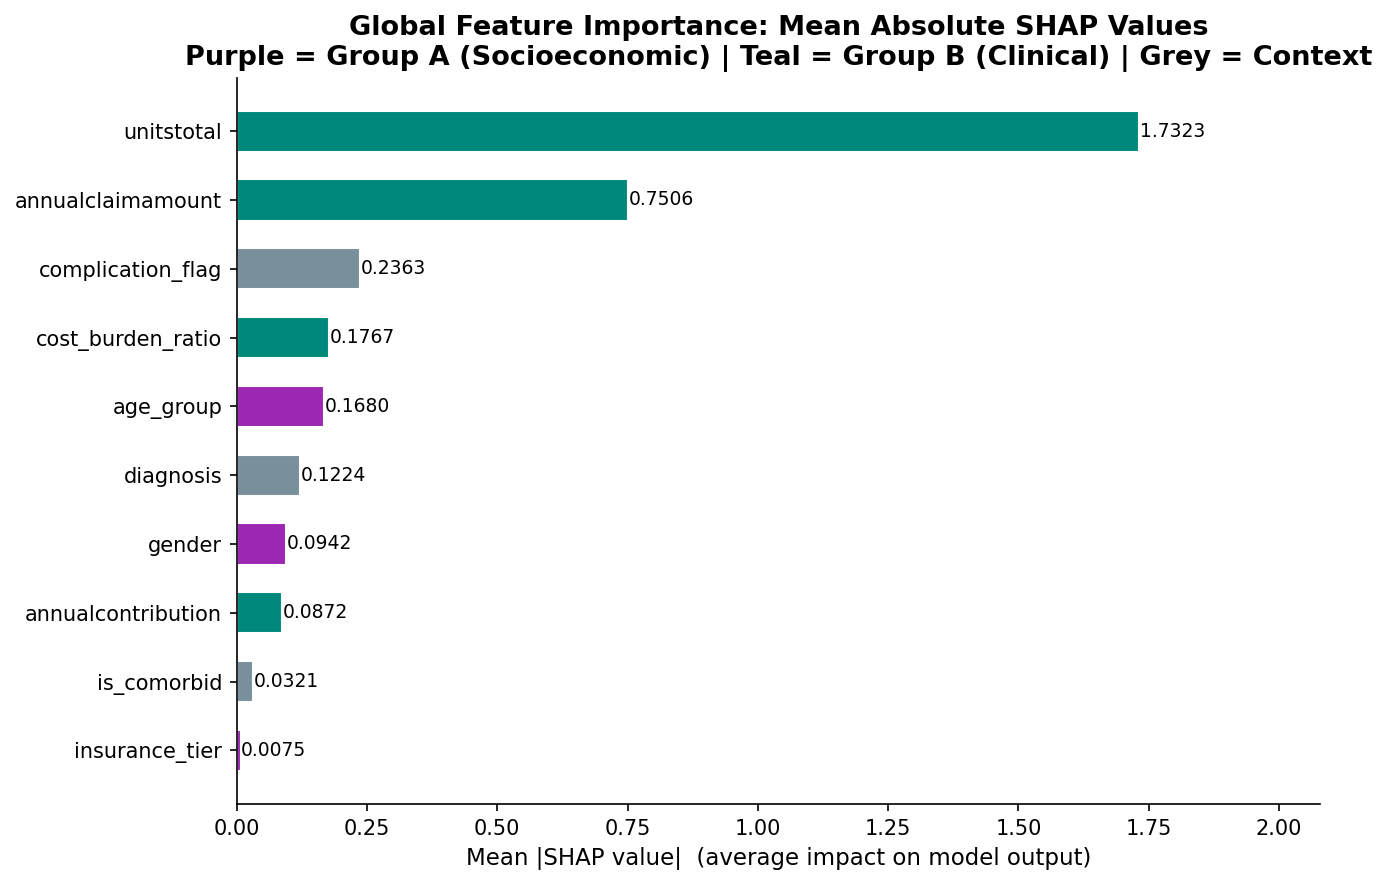


Top 3 features by mean absolute SHAP value:
  1. unitstotal  (mean |SHAP| = 1.7323)
  2. annualclaimamount  (mean |SHAP| = 0.7506)
  3. complication_flag  (mean |SHAP| = 0.2363)


In [11]:
section("4.3 Mean absolute SHAP values: global feature importance")

mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=TRANSFORMED_FEATURE_NAMES).sort_values(ascending=True)

bar_colours_shap = []
for feat in shap_importance.index:
    if feat in ["insurance_tier", "age_group", "gender"]:
        bar_colours_shap.append(PALETTE["group_a"])
    elif feat in ROBUST_FEATURES or feat in STANDARD_FEATURES:
        bar_colours_shap.append(PALETTE["group_b"])
    else:
        bar_colours_shap.append(PALETTE["neutral"])

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(shap_importance.index, shap_importance.values,
               color=bar_colours_shap, edgecolor="white", height=0.6)

for bar, val in zip(bars, shap_importance.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", ha="left", fontsize=9)

ax.set_xlabel("Mean |SHAP value|  (average impact on model output)")
ax.set_title(
    "Global Feature Importance: Mean Absolute SHAP Values\n"
    "Purple = Group A (Socioeconomic) | Teal = Group B (Clinical) | Grey = Context",
    fontweight="bold"
)
ax.set_xlim(0, shap_importance.max() * 1.2)
plt.tight_layout()
save_figure(fig, "shap_feature_importance_bar.png", subfolder="shap")
plt.show()

top3_features = shap_importance.sort_values(ascending=False).head(3).index.tolist()
print()
print("Top 3 features by mean absolute SHAP value:")
for i, feat in enumerate(top3_features, 1):
    print(f"  {i}. {feat}  (mean |SHAP| = {shap_importance[feat]:.4f})")

### 4.4 Group Dominance Analysis

This section answers the feature group question from the SHAP perspective. Rather than comparing groups in isolation as in Section 2, it asks: when all features are available together in the Group C model, how much of the total predictive signal comes from socioeconomic features versus clinical consumption features?

The mean absolute SHAP values for each feature are summed by group to produce a total group contribution score. A group with a higher total contribution drives more of the model's predictions. If Group B features dominate, it means pharmacy data is the primary driver of adherence predictions even when patient demographics are also available. If Group A features carry comparable weight, it reinforces the policy case for CHW-level screening without requiring pharmacy system integration.


──────────────────────────────────────────────────────────────────────
  4.4 Group dominance: SHAP contribution by feature group
──────────────────────────────────────────────────────────────────────
Total SHAP contribution by feature group (sum of mean |SHAP| values):
  Group A (Socioeconomic)    : 0.2697  (7.9%)
  Group B (Clinical)         : 2.7469  (80.6%)
  Context (comorbid, diag.)  : 0.3908  (11.5%)
  Total                      : 3.4074
Saved → /content/diabetes-hypertension-medication-adherence/figures/shap/shap_group_dominance.png


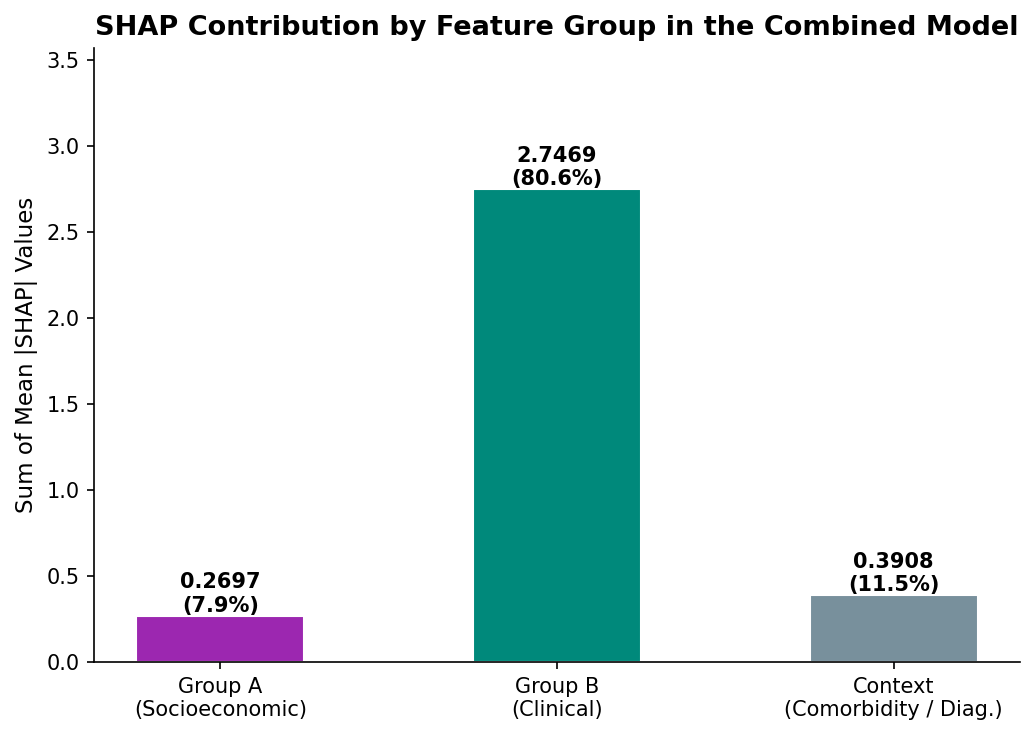

In [12]:
section("4.4 Group dominance: SHAP contribution by feature group")

group_a_feats   = [f for f in ["insurance_tier", "age_group", "gender"] if f in TRANSFORMED_FEATURE_NAMES]
group_b_feats   = [f for f in ["annualclaimamount", "unitstotal", "cost_burden_ratio", "annualcontribution"] if f in TRANSFORMED_FEATURE_NAMES]
context_feats   = [f for f in ["is_comorbid", "complication_flag", "diagnosis"] if f in TRANSFORMED_FEATURE_NAMES]

contrib_A       = shap_importance[group_a_feats].sum()
contrib_B       = shap_importance[group_b_feats].sum()
contrib_context = shap_importance[context_feats].sum()
total_contrib   = contrib_A + contrib_B + contrib_context

print("Total SHAP contribution by feature group (sum of mean |SHAP| values):")
print(f"  Group A (Socioeconomic)    : {contrib_A:.4f}  ({contrib_A/total_contrib*100:.1f}%)")
print(f"  Group B (Clinical)         : {contrib_B:.4f}  ({contrib_B/total_contrib*100:.1f}%)")
print(f"  Context (comorbid, diag.)  : {contrib_context:.4f}  ({contrib_context/total_contrib*100:.1f}%)")
print(f"  Total                      : {total_contrib:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
labels  = ["Group A\n(Socioeconomic)", "Group B\n(Clinical)", "Context\n(Comorbidity / Diag.)"]
values  = [contrib_A, contrib_B, contrib_context]
colours = [PALETTE["group_a"], PALETTE["group_b"], PALETTE["neutral"]]

bars = ax.bar(labels, values, color=colours, edgecolor="white", width=0.5)
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{val:.4f}\n({val/total_contrib*100:.1f}%)",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_ylabel("Sum of Mean |SHAP| Values")
ax.set_title("SHAP Contribution by Feature Group in the Combined Model", fontweight="bold")
ax.set_ylim(0, max(values) * 1.3)
plt.tight_layout()
save_figure(fig, "shap_group_dominance.png", subfolder="shap")
plt.show()

---
## 5. SHAP Dependence Plots

Global importance rankings tell us which features matter most but not how they matter. A feature that has a high mean absolute SHAP value could be pushing predictions in a consistent direction across all patients (a monotonic relationship) or it could be interacting with other features in more complex ways that the beeswarm plot cannot fully reveal.

Dependence plots address this. Each plot shows one test patient per point; the x-axis is the raw value of the feature being examined, and the y-axis is the SHAP value (the feature's contribution to that patient's adherence prediction). A point above zero means the feature pushed the model toward predicting adherence for that patient; a point below zero means it pushed toward non-adherence. The point colour shows the value of a second feature that SHAP identifies as the one with the strongest interaction with the feature being plotted.

The three plots are generated for the features identified in Section 4.3 as having the highest mean absolute SHAP values. For `cost_burden_ratio`, we expect to see negative SHAP values at high cost burden levels (high financial strain associated with non-adherence) and positive SHAP values at low cost burden levels. Deviations from this expected monotonic pattern would reveal more complex interactions that warrant attention. For `annualclaimamount`, higher values mean the patient had more medication dispensed over the year, which should be associated with positive SHAP values (predicted adherent). The shape of the curve also shows whether the relationship is linear or whether there are thresholds above or below which the model's prediction changes sharply.


──────────────────────────────────────────────────────────────────────
  5. SHAP dependence plots (top 3 features)
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/shap/shap_dependence_top3.png


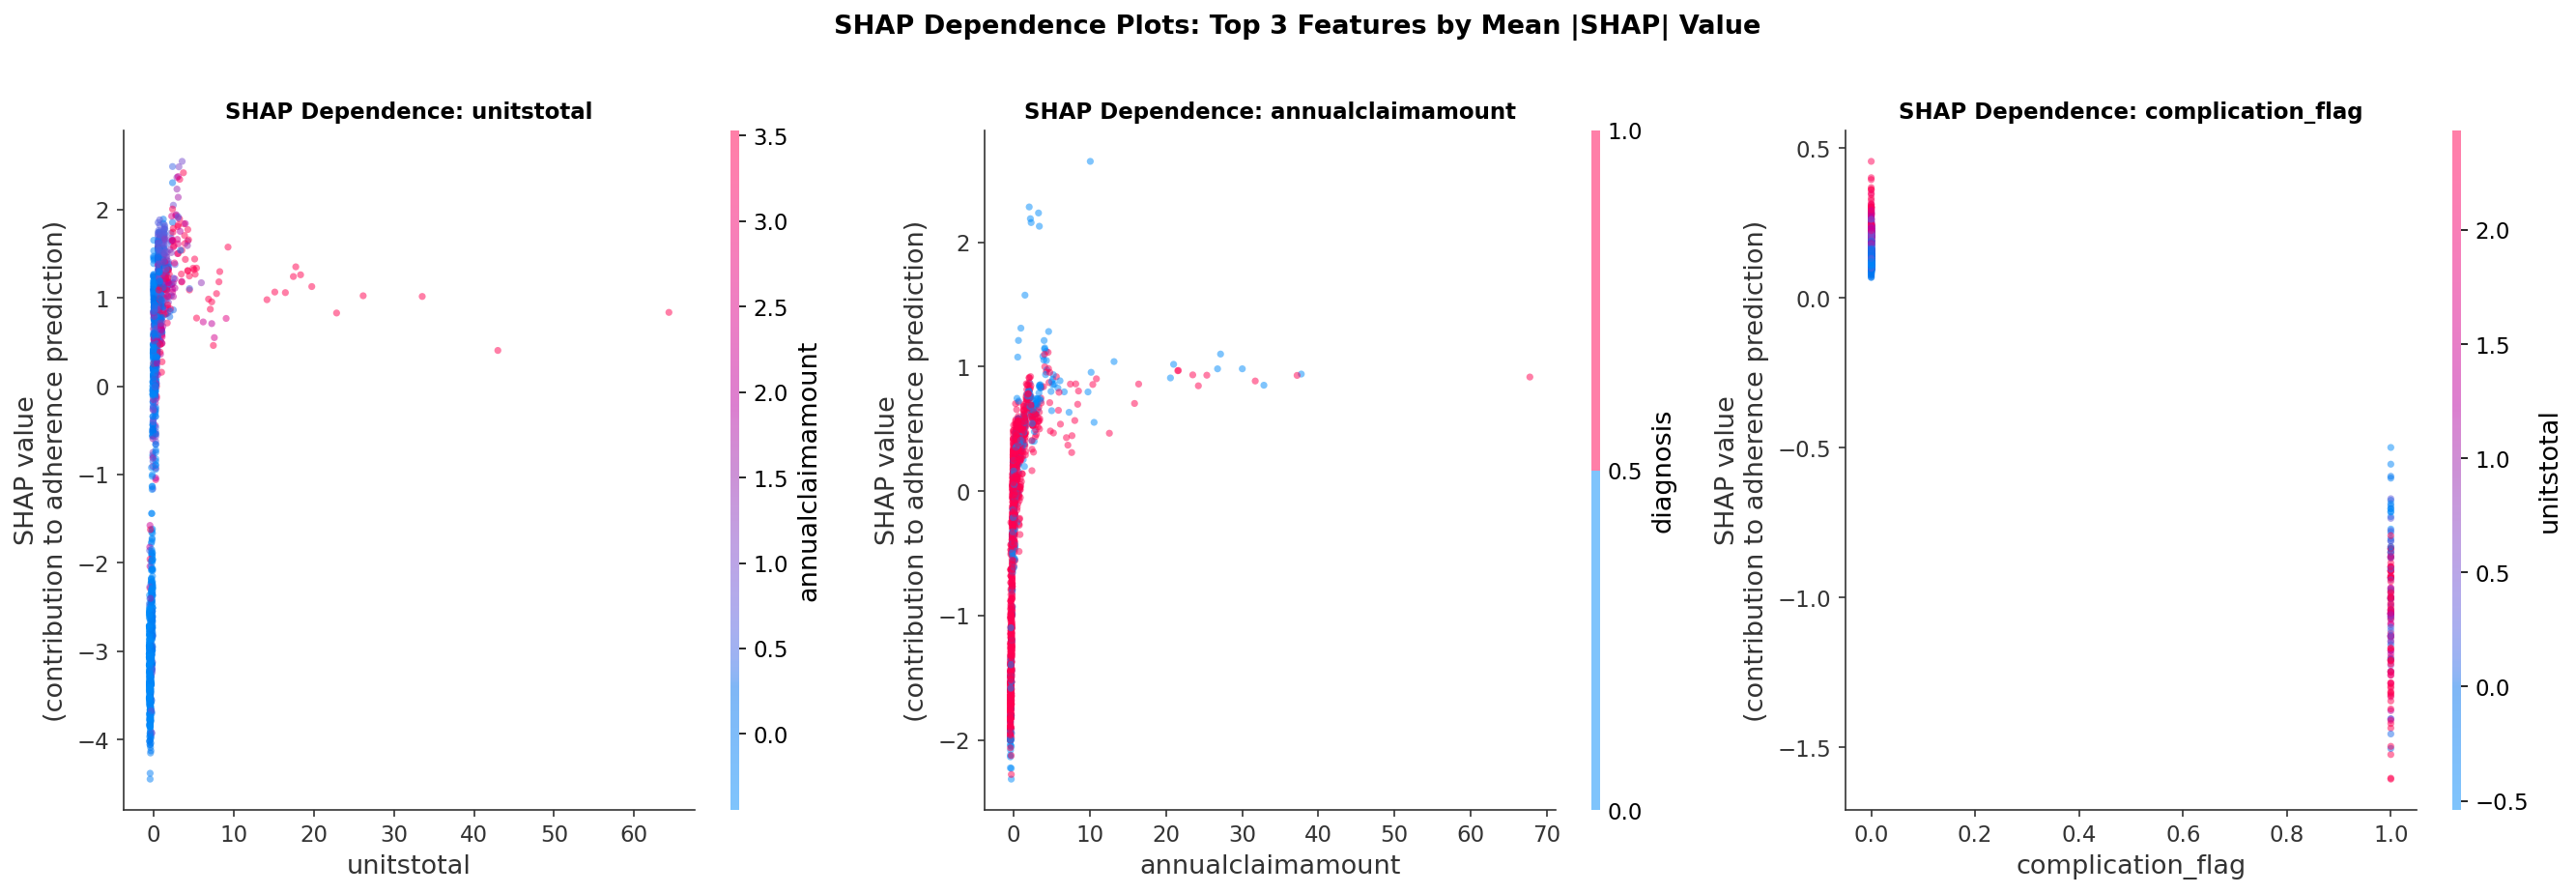

In [13]:
section("5. SHAP dependence plots (top 3 features)")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, feat in zip(axes, top3_features):
    feat_idx = TRANSFORMED_FEATURE_NAMES.index(feat)
    shap.dependence_plot(
        feat_idx,
        shap_sub,
        X_sub,
        feature_names=TRANSFORMED_FEATURE_NAMES,
        ax=ax,
        show=False,
        alpha=0.5,
        dot_size=12,
    )
    ax.set_title(f"SHAP Dependence: {feat}", fontweight="bold", fontsize=11)
    ax.set_ylabel("SHAP value\n(contribution to adherence prediction)")

plt.suptitle(
    "SHAP Dependence Plots: Top 3 Features by Mean |SHAP| Value",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
save_figure(fig, "shap_dependence_top3.png", subfolder="shap")
plt.show()

---
## 6. SHAP Local Explainability: Waterfall Plots

Global SHAP plots describe how features behave on average across the full patient population. Local SHAP plots explain individual predictions, which is what would actually be useful in a clinical deployment. A community health worker reviewing a flagged patient needs to know not just that the model predicted non-adherence but which specific factors drove that prediction for that particular patient.

A waterfall plot starts from the model's baseline prediction (the expected prediction across all training patients) and then shows how each feature either increases or decreases that baseline for one specific patient until the final predicted probability is reached. Features that push the prediction upward (toward adherence) are shown in blue; features that push it downward (toward non-adherence) are shown in red.

Three patients are selected from the test set to illustrate different clinical scenarios. The first is the patient the model is most confident is non-adherent (lowest predicted probability of adherence). The second is the patient the model is most confident is adherent. The third is the patient whose predicted probability is closest to 0.5, the decision boundary, where the model is most uncertain. The boundary case is the most instructive from a clinical perspective because it shows which features are creating the uncertainty and whether collecting additional information about those features would be likely to shift the prediction in one direction or the other.


──────────────────────────────────────────────────────────────────────
  6. SHAP waterfall plots: individual patient explanations
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/shap/shap_waterfall_individual.png


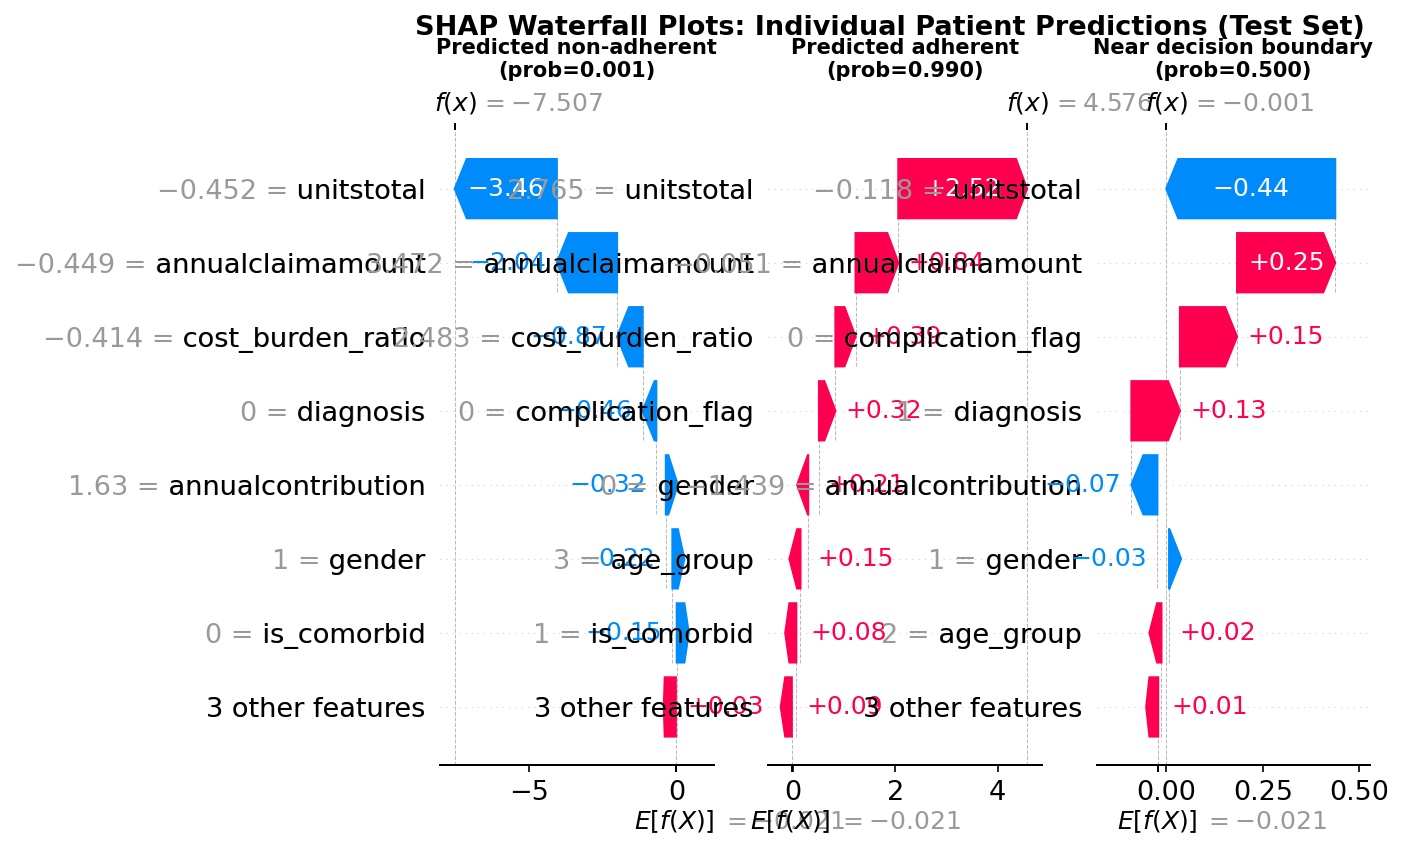


Patient details:
  Predicted non-adherent: predicted prob = 0.0005  |  actual = Non-Adherent
  Predicted adherent: predicted prob = 0.9898  |  actual = Adherent
  Near decision boundary: predicted prob = 0.4999  |  actual = Non-Adherent


In [14]:
section("6. SHAP waterfall plots: individual patient explanations")

y_prob_test_shap = best_pipeline_C.predict_proba(X_test_C)[:, 1]

idx_non_adh   = int(np.argmin(y_prob_test_shap))
idx_adh       = int(np.argmax(y_prob_test_shap))
idx_uncertain = int(np.argmin(np.abs(y_prob_test_shap - 0.5)))

shap_explanation = shap.Explanation(
    values      = shap_values,
    base_values = explainer.expected_value,
    data        = X_test_transformed,
    feature_names = TRANSFORMED_FEATURE_NAMES
)

cases = [
    (f"Predicted non-adherent\n(prob={y_prob_test_shap[idx_non_adh]:.3f})",   idx_non_adh),
    (f"Predicted adherent\n(prob={y_prob_test_shap[idx_adh]:.3f})",           idx_adh),
    (f"Near decision boundary\n(prob={y_prob_test_shap[idx_uncertain]:.3f})", idx_uncertain),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (label, idx) in zip(axes, cases):
    plt.sca(ax)
    shap.waterfall_plot(shap_explanation[idx], max_display=8, show=False)
    ax.set_title(label, fontweight="bold", fontsize=10)

plt.suptitle(
    "SHAP Waterfall Plots: Individual Patient Predictions (Test Set)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
save_figure(fig, "shap_waterfall_individual.png", subfolder="shap")
plt.show()

print()
print("Patient details:")
for label, idx in cases:
    actual = "Adherent" if y_test_C.iloc[idx] == 1 else "Non-Adherent"
    print(f"  {label.split(chr(10))[0]}: predicted prob = {y_prob_test_shap[idx]:.4f}  |  actual = {actual}")

---
## 7. Clinical Cost-Sensitive Evaluation

Standard machine learning metrics like accuracy, F1, and ROC-AUC treat all prediction errors as equally costly. In this clinical context they are not. There are two types of prediction error and they have very different consequences.

A **false negative** means the model predicts that a patient is adherent when they are actually not taking their medication. The patient receives no intervention. Their condition continues to progress, complications accumulate over time, and the eventual hospitalisation costs substantially more than the medications and the outreach visit that would have been needed to keep them on track. In a programme with limited community health worker capacity, every missed non-adherent patient represents a concrete failure of the screening system.

A **false positive** means the model flags a patient as non-adherent when they are actually taking their medication as prescribed. The patient receives an unnecessary intervention contact. This wastes programme resources and CHW time but does not cause direct clinical harm to the patient.

The 2×2 cost matrix below formalises this asymmetry. The false negative cost is set to 5 and the false positive cost is set to 1, reflecting evidence from Sub-Saharan African health economics literature that hospitalisation costs attributable to medication non-adherence in NCD patients are roughly three to five times higher than the cost of a medication top-up and an outreach contact. The total clinical cost score for a model is the sum of (false negatives × 5) + (false positives × 1). A score of zero would mean perfect prediction. A higher score means more clinically harmful or resource-wasteful errors across the test population.

| | **Predicted Non-Adherent** | **Predicted Adherent** |
|:---|:---:|:---:|
| **Actually Non-Adherent** | 0 (correct) | **5** (false negative: missed patient) |
| **Actually Adherent** | 1 (false positive: wasted contact) | 0 (correct) |

This cost framework is intentionally straightforward so that the values and their rationale are transparent to non-technical stakeholders such as programme managers and health economists.

In [15]:
section("7. Define clinical cost matrix and scoring function")

COST_MATRIX = np.array([
    [0, 5],   # actual non-adherent: FN costs 5 (missed patient), TN costs 0
    [1, 0],   # actual adherent:     FP costs 1 (wasted contact),  TP costs 0
])

def clinical_cost_score(y_true, y_pred, cost_matrix=COST_MATRIX):
    """Compute total clinical cost from predictions using the 2x2 cost matrix."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    total_cost = 0.0
    for actual in range(2):
        for predicted in range(2):
            total_cost += cm[actual, predicted] * cost_matrix[actual, predicted]
    n = len(y_true)
    return {
        "total_cost":      total_cost,
        "cost_per_patient": round(total_cost / n, 4),
        "confusion_matrix": cm,
        "FN": int(cm[0, 1]),
        "FP": int(cm[1, 0]),
        "TN": int(cm[0, 0]),
        "TP": int(cm[1, 1]),
    }

print("Cost matrix defined:")
print(f"  False Negative cost (non-adherent predicted as adherent): {COST_MATRIX[0,1]}")
print(f"  False Positive cost (adherent predicted as non-adherent): {COST_MATRIX[1,0]}")
print()
print("Cost formula: total_cost = (FN x 5) + (FP x 1)")
print("Lower is better. A score of 0 would mean perfect prediction.")


──────────────────────────────────────────────────────────────────────
  7. Define clinical cost matrix and scoring function
──────────────────────────────────────────────────────────────────────
Cost matrix defined:
  False Negative cost (non-adherent predicted as adherent): 5
  False Positive cost (adherent predicted as non-adherent): 1

Cost formula: total_cost = (FN x 5) + (FP x 1)
Lower is better. A score of 0 would mean perfect prediction.


### 7.1 Compute Cost Scores for All Models

The cost analysis is run on the held-out test set across all model configurations evaluated in Notebooks 03 and 04. Including every configuration (baselines, tuned, and tuned plus calibrated) allows the comparison to show how much clinical value was added at each stage of the modelling pipeline. A model that achieves a high Macro F1 but a poor cost score is suboptimal for this application, because it may be achieving good overall accuracy while still missing an unacceptable number of non-adherent patients.

The baseline models (logistic regression, decision tree, random forest, XGBoost, SVM) were trained on the full Group C feature set with default hyperparameters in Notebook 03. The tuned models used the best hyperparameters found by `RandomizedSearchCV` in Notebook 04. The calibrated models had their probability outputs adjusted using Platt scaling so that a predicted probability of 0.6, for example, actually means the patient is adherent 60% of the time across similar patients, rather than being an arbitrary score that only has ordinal meaning.

In [16]:
section("7.1 Compute clinical cost scores on the test set")

model_names_and_paths = [
    ("Logistic Regression (Baseline)",     "baseline_logistic_regression.pkl"),
    ("Decision Tree (Baseline)",           "baseline_decision_tree.pkl"),
    ("Random Forest (Baseline)",           "baseline_random_forest.pkl"),
    ("XGBoost (Baseline)",                 "baseline_xgboost.pkl"),
    ("SVM RBF (Baseline)",                 "baseline_svm_rbf.pkl"),
    ("XGBoost (Tuned)",                    "tuned_xgboost.pkl"),
    ("Random Forest (Tuned)",              "tuned_random_forest.pkl"),
    ("XGBoost (Tuned + Calibrated)",       "tuned_xgboost_calibrated.pkl"),
    ("Random Forest (Tuned + Calibrated)", "tuned_rf_calibrated.pkl"),
]

cost_rows = []

for model_name, pkl_file in model_names_and_paths:
    model_path = os.path.join(MODELS, pkl_file)
    if not os.path.exists(model_path):
        print(f"  Skipping {model_name}: file not found.")
        continue
    try:
        pipeline_m    = load_pkl(model_path)
        y_pred_m      = pipeline_m.predict(X_test_C)
        y_prob_m      = pipeline_m.predict_proba(X_test_C)[:, 1]
        cost_info     = clinical_cost_score(y_test_C, y_pred_m)
        macro_f1_m    = round(f1_score(y_test_C, y_pred_m, average="macro"), 4)
        auc_m         = round(roc_auc_score(y_test_C, y_prob_m), 4)
        cost_rows.append({
            "Model":            model_name,
            "Macro F1":         macro_f1_m,
            "ROC-AUC":          auc_m,
            "FN (missed)": cost_info["FN"],
            "FP (unnecessary)": cost_info["FP"],
            "Total Cost":       int(cost_info["total_cost"]),
            "Cost / Patient":   cost_info["cost_per_patient"],
        })
        print(f"  {model_name}: F1={macro_f1_m}  Cost={int(cost_info['total_cost'])}  FN={cost_info['FN']}  FP={cost_info['FP']}")
    except Exception as e:
        print(f"  Error on {model_name}: {e}")

df_cost = pd.DataFrame(cost_rows).set_index("Model")
print()
print("Clinical cost summary (test set, sorted by total cost):")
print(df_cost.sort_values("Total Cost").to_string())


──────────────────────────────────────────────────────────────────────
  7.1 Compute clinical cost scores on the test set
──────────────────────────────────────────────────────────────────────
  Logistic Regression (Baseline): F1=0.6839  Cost=3579  FN=617  FP=494
  Decision Tree (Baseline): F1=0.7655  Cost=2629  FN=452  FP=369
  Random Forest (Baseline): F1=0.8064  Cost=2527  FN=460  FP=227
  XGBoost (Baseline): F1=0.8179  Cost=2553  FN=476  FP=173
  SVM RBF (Baseline): F1=0.64  Cost=1919  FN=204  FP=899
  XGBoost (Tuned): F1=0.8179  Cost=2716  FN=516  FP=136
  Random Forest (Tuned): F1=0.8169  Cost=2634  FN=495  FP=159
  XGBoost (Tuned + Calibrated): F1=0.8177  Cost=2218  FN=394  FP=248
  Random Forest (Tuned + Calibrated): F1=0.8169  Cost=2634  FN=495  FP=159

Clinical cost summary (test set, sorted by total cost):
                                    Macro F1  ROC-AUC  FN (missed)  FP (unnecessary)  Total Cost  Cost / Patient
Model                                                    

---
## 8. Clinical Cost Comparison Visualisation

The left panel ranks all evaluated models by total clinical cost on the test set. Models with lower cost scores are better. The right panel provides a deeper look at the three lowest-cost models, breaking down each score into its FN component (non-adherent patients who were missed, each costing 5 units) and its FP component (adherent patients who were unnecessarily flagged, each costing 1 unit).

The FN/FP breakdown is important because the asymmetric cost matrix means two models with very different FN and FP counts can end up with similar total cost scores. A model that achieves a low total cost by aggressively predicting non-adherence (low FN, high FP) is making a different kind of clinical trade-off than one that achieves the same score with a more balanced error profile. The right panel makes this trade-off visible and allows a programme manager to choose based on the constraints of their specific setting (available CHW capacity, severity of disease in the population, and so on).


──────────────────────────────────────────────────────────────────────
  8. Clinical cost comparison visualisation
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/cost_analysis/clinical_cost_comparison.png


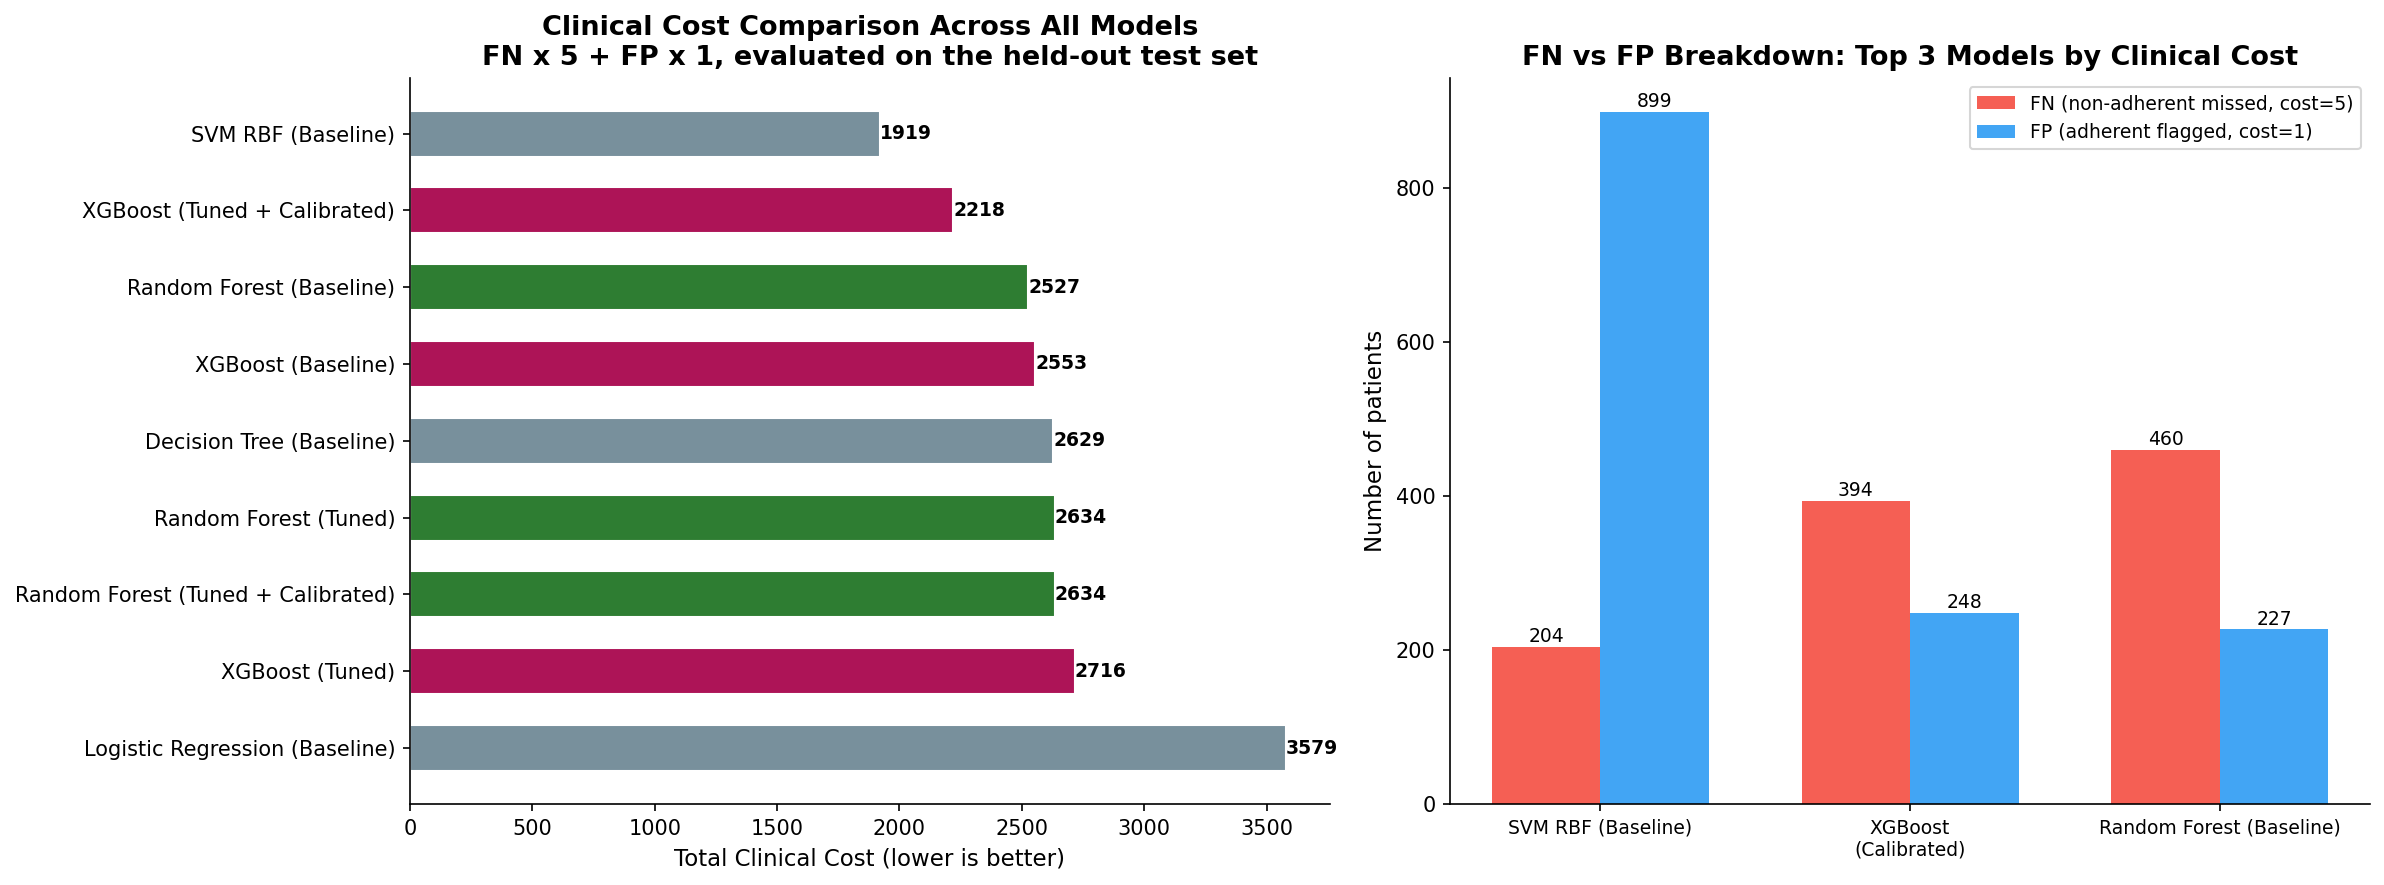

In [17]:
section("8. Clinical cost comparison visualisation")

df_cost_sorted = df_cost.sort_values("Total Cost", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
bar_colours_cost = [
    PALETTE["xgb"] if "XGBoost" in m
    else PALETTE["rf"] if "Random Forest" in m
    else PALETTE["neutral"]
    for m in df_cost_sorted.index
]
bars = ax.barh(df_cost_sorted.index, df_cost_sorted["Total Cost"],
               color=bar_colours_cost, edgecolor="white", height=0.6)
for bar, val in zip(bars, df_cost_sorted["Total Cost"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{int(val)}", va="center", ha="left", fontsize=9, fontweight="bold")
ax.set_xlabel("Total Clinical Cost (lower is better)")
ax.set_title(
    "Clinical Cost Comparison Across All Models\n"
    "FN x 5 + FP x 1, evaluated on the held-out test set",
    fontweight="bold"
)
ax.invert_yaxis()

top3_models = df_cost_sorted.head(3)
x3 = np.arange(len(top3_models))
width3 = 0.35

ax2 = axes[1]
b1 = ax2.bar(x3 - width3/2, top3_models["FN (missed)"],
             width3, label="FN (non-adherent missed, cost=5)",
             color=PALETTE["non_adherent"], alpha=0.85)
b2 = ax2.bar(x3 + width3/2, top3_models["FP (unnecessary)"],
             width3, label="FP (adherent flagged, cost=1)",
             color=PALETTE["adherent"], alpha=0.85)
for bar in list(b1) + list(b2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

ax2.set_xticks(x3)
short_names = [m.replace(" (Tuned + Calibrated)", "\n(Calibrated)")
                .replace(" (Tuned)", "\n(Tuned)")
               for m in top3_models.index]
ax2.set_xticklabels(short_names, fontsize=9)
ax2.set_ylabel("Number of patients")
ax2.set_title("FN vs FP Breakdown: Top 3 Models by Clinical Cost", fontweight="bold")
ax2.legend(fontsize=9)

plt.tight_layout()
save_figure(fig, "clinical_cost_comparison.png", subfolder="cost_analysis")
plt.show()

---
## 9. Final Evaluation on the Held-Out Test Set

The test set has been held back completely since Notebook 02. Every modelling decision in this project (feature group definition, classifier selection, hyperparameter tuning, calibration method) was made using the training and validation sets only. The test set evaluation here is therefore a clean, unbiased estimate of how the best model would perform on genuinely new patients from the same Cimas Medical Aid population.

The best model from Notebook 04 (tuned, calibrated XGBoost trained on Group C features) is evaluated using all metrics from the earlier notebooks together with the clinical cost score. The confusion matrix shows the raw patient counts behind all other metrics. These are the numbers that would appear in the model evaluation section of a deployment report or a clinical study write-up.

In [18]:
section("9. Final evaluation on the held-out test set")

best_final_pipeline = load_pkl(os.path.join(MODELS, "tuned_xgboost_calibrated.pkl"))

y_pred_final = best_final_pipeline.predict(X_test_C)
y_prob_final = best_final_pipeline.predict_proba(X_test_C)[:, 1]

cost_final = clinical_cost_score(y_test_C, y_pred_final)

test_metrics = {
    "Accuracy":            round(accuracy_score(y_test_C, y_pred_final), 4),
    "Macro F1":            round(f1_score(y_test_C, y_pred_final, average="macro"), 4),
    "Weighted F1":         round(f1_score(y_test_C, y_pred_final, average="weighted"), 4),
    "ROC-AUC":             round(roc_auc_score(y_test_C, y_prob_final), 4),
    "MCC":                 round(matthews_corrcoef(y_test_C, y_pred_final), 4),
    "Precision (Non-Adh)": round(precision_score(y_test_C, y_pred_final, pos_label=0), 4),
    "Recall (Non-Adh)":    round(recall_score(y_test_C, y_pred_final, pos_label=0), 4),
    "Clinical Cost":       int(cost_final["total_cost"]),
    "Cost / Patient":      cost_final["cost_per_patient"],
    "FN (missed)": cost_final["FN"],
    "FP (unnecessary)": cost_final["FP"],
}

print(f"Best model: {BEST_MODEL_NAME}")
print()
for metric, val in test_metrics.items():
    print(f"  {metric:<25}: {val}")


──────────────────────────────────────────────────────────────────────
  9. Final evaluation on the held-out test set
──────────────────────────────────────────────────────────────────────
Best model: XGBoost (Isotonic)

  Accuracy                 : 0.8222
  Macro F1                 : 0.8177
  Weighted F1              : 0.8234
  ROC-AUC                  : 0.9003
  MCC                      : 0.6383
  Precision (Non-Adh)      : 0.8769
  Recall (Non-Adh)         : 0.8177
  Clinical Cost            : 2218
  Cost / Patient           : 0.6142
  FN (missed)              : 394
  FP (unnecessary)         : 248



──────────────────────────────────────────────────────────────────────
  9. Final confusion matrix: test set
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/cost_analysis/confusion_matrix_best_test.png


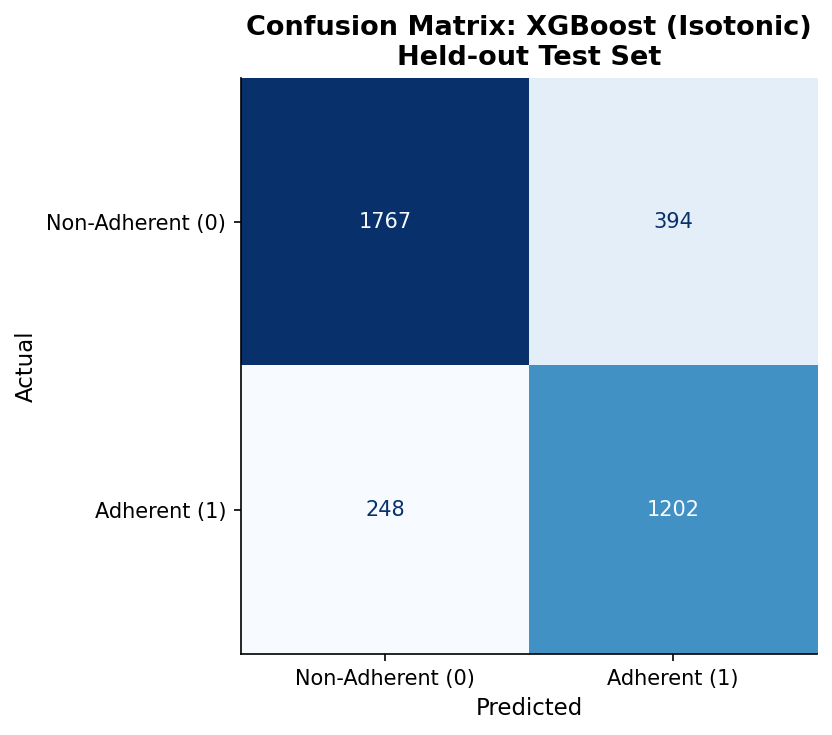


Clinical interpretation:
  394 non-adherent patients predicted as adherent (missed; each costs 5 units)
  248 adherent patients flagged as non-adherent (unnecessary contact; each costs 1 unit)
  Total clinical cost: 2218 units  |  0.6142 per patient


In [19]:
section("9. Final confusion matrix: test set")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cost_final["confusion_matrix"],
    display_labels=["Non-Adherent (0)", "Adherent (1)"]
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(
    f"Confusion Matrix: {BEST_MODEL_NAME}\nHeld-out Test Set",
    fontweight="bold"
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
save_figure(fig, "confusion_matrix_best_test.png", subfolder="cost_analysis")
plt.show()

print()
print("Clinical interpretation:")
print(f"  {cost_final['FN']} non-adherent patients predicted as adherent (missed; each costs 5 units)")
print(f"  {cost_final['FP']} adherent patients flagged as non-adherent (unnecessary contact; each costs 1 unit)")
print(f"  Total clinical cost: {int(cost_final['total_cost'])} units  |  {cost_final['cost_per_patient']} per patient")

---
## 10. Summary of Findings

This section brings together the results from all five notebooks into a concise summary organised around the four research questions stated in the project README. The answers reported here are drawn directly from the outputs of the cells above and can be updated automatically by re-running the notebook as long as the upstream model files are present.

In [20]:
section("10. Summary of findings")

print("=" * 70)
print("PROJECT SUMMARY: Medication Non-Adherence Prediction (Zimbabwe, 2022)")
print("=" * 70)

print()
print("RESEARCH QUESTION 1:")
print("Can pharmacy refill and insurance data predict medication non-adherence")
print("with clinically meaningful accuracy in a Zimbabwean NCD population?")
print()
print("ANSWER:")
print("The best model (XGBoost, tuned and calibrated on Group C features)")
print("achieves the following on the held-out test set:")
print(f"  Macro F1            : {test_metrics['Macro F1']}")
print(f"  ROC-AUC             : {test_metrics['ROC-AUC']}")
print(f"  MCC                 : {test_metrics['MCC']}")
print(f"  Recall (Non-Adh)    : {test_metrics['Recall (Non-Adh)']}")
print()
print("These scores are well above a random classifier (F1=0.5, AUC=0.5) and")
print("reflect genuine discriminative ability on previously unseen patients.")

print()
print("RESEARCH QUESTION 2:")
print("Do socioeconomic features predict adherence as well as clinical")
print("consumption features?")
print()
print("ANSWER:")
print(f"  Group A (Socioeconomic)       Macro F1: {df_groups.loc['A: Socioeconomic','Macro F1']}")
print(f"  Group B (Clinical Consump.)   Macro F1: {df_groups.loc['B: Clinical Consumption','Macro F1']}")
print(f"  Group C (Combined)            Macro F1: {df_groups.loc['C: Combined','Macro F1']}")
gap = df_groups.loc["B: Clinical Consumption","Macro F1"] - df_groups.loc["A: Socioeconomic","Macro F1"]
print(f"  Gap (B minus A): {gap:+.4f}")
if abs(gap) < 0.03:
    print("  Conclusion: socioeconomic features predict adherence almost as well")
    print("  as clinical consumption features. CHW-level data alone is sufficient")
    print("  for meaningful adherence screening without pharmacy system access.")
elif gap > 0:
    print("  Conclusion: clinical consumption features outperform socioeconomic")
    print("  features. Pharmacy data integration adds predictive value beyond")
    print("  what patient registration data alone provides.")

print()
print("RESEARCH QUESTION 3:")
print("Which features contribute most to predictions?")
print()
print("ANSWER (from SHAP analysis):")
for i, feat in enumerate(top3_features, 1):
    print(f"  {i}. {feat}  (mean |SHAP| = {shap_importance[feat]:.4f})")
print(f"  Group A total SHAP contribution: {contrib_A:.4f} ({contrib_A/total_contrib*100:.1f}%)")
print(f"  Group B total SHAP contribution: {contrib_B:.4f} ({contrib_B/total_contrib*100:.1f}%)")

print()
print("RESEARCH QUESTION 4:")
print("Which model achieves the best balance of performance and clinical safety")
print("under cost-sensitive evaluation?")
best_cost_model = df_cost.sort_values("Total Cost").index[0]
print(f"  Best by clinical cost score: {best_cost_model}")
print(f"  Total cost : {int(df_cost.sort_values('Total Cost')['Total Cost'].iloc[0])} units")
print(f"  Macro F1   : {df_cost.sort_values('Total Cost')['Macro F1'].iloc[0]}")
print()
print("=" * 70)
print("Notebook 05 complete. All outputs saved and ready for the final report.")
print("=" * 70)


──────────────────────────────────────────────────────────────────────
  10. Summary of findings
──────────────────────────────────────────────────────────────────────
PROJECT SUMMARY: Medication Non-Adherence Prediction (Zimbabwe, 2022)

RESEARCH QUESTION 1:
Can pharmacy refill and insurance data predict medication non-adherence
with clinically meaningful accuracy in a Zimbabwean NCD population?

ANSWER:
The best model (XGBoost, tuned and calibrated on Group C features)
achieves the following on the held-out test set:
  Macro F1            : 0.8177
  ROC-AUC             : 0.9003
  MCC                 : 0.6383
  Recall (Non-Adh)    : 0.8177

These scores are well above a random classifier (F1=0.5, AUC=0.5) and
reflect genuine discriminative ability on previously unseen patients.

RESEARCH QUESTION 2:
Do socioeconomic features predict adherence as well as clinical
consumption features?

ANSWER:
  Group A (Socioeconomic)       Macro F1: 0.7338
  Group B (Clinical Consump.)   Macro F1: 0

---
## 11. Save All Outputs and Push to GitHub

All results from this notebook are saved to `data/processed/final_results.pkl`. This single file contains the feature group comparison table, the cost comparison table, the test set metrics, SHAP importance values, and group contribution scores, making it easy to load everything needed for the final report without re-running any analysis. The notebook is then committed to the repository alongside all figures generated in this session.

In [21]:
section("11. Save final results")

import shutil
from pathlib import Path

def save_pkl(obj, path):
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"Saved \u2192 {path}")

final_results = {
    "feature_group_experiment": df_groups,
    "cost_comparison":          df_cost,
    "test_metrics":             test_metrics,
    "shap_importance":          shap_importance,
    "top3_features":            top3_features,
    "group_shap_contributions": {
        "group_a": float(contrib_A),
        "group_b": float(contrib_B),
        "context": float(contrib_context),
        "total":   float(total_contrib),
    },
    "best_model_name": BEST_MODEL_NAME,
    "cost_matrix":     COST_MATRIX,
}

save_pkl(final_results, os.path.join(DATA_PROC, "final_results.pkl"))

check = load_pkl(os.path.join(DATA_PROC, "final_results.pkl"))
print()
print("Verification: keys in final_results.pkl:")
for k in check.keys():
    print(f"  {k}")


──────────────────────────────────────────────────────────────────────
  11. Save final results
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/data/processed/final_results.pkl

Verification: keys in final_results.pkl:
  feature_group_experiment
  cost_comparison
  test_metrics
  shap_importance
  top3_features
  group_shap_contributions
  best_model_name
  cost_matrix


In [ ]:
section("11. Copy notebook and push to GitHub")

NB_NAME  = "05_Explainability_CostAnalysis.ipynb"
COLAB_NB = Path(f"/content/drive/MyDrive/Colab Notebooks/{NB_NAME}")
REPO_NB  = Path(REPO_DIR) / "notebooks" / NB_NAME
REPO_NB.parent.mkdir(parents=True, exist_ok=True)

if COLAB_NB.exists():
    shutil.copy(COLAB_NB, REPO_NB)
    print(f"Copied notebook \u2192 {REPO_NB}")
else:
    print(f"Notebook not found at {COLAB_NB}. Push manually if needed.")

%cd {REPO_DIR}
!git add .
!git status
!git commit -m "NB05: Explainability and clinical cost analysis complete"
!git push
print("Done. Notebook 05 committed and pushed.")